# Import Statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

In [3]:
import pandas as pd
import numpy as np
import sklearn

from sklearn.preprocessing import OneHotEncoder
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns


/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.linear_model import Lasso

from sklearn.metrics import accuracy_score


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [6]:
import tqdm as notebook_tqdm
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [5]:
from platform import python_version

print(python_version())


3.10.12


In [30]:
print(np.__version__)

1.26.3


# Define all functions

In [31]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}

# set parameter space for LASSO

lasso_space = {
    'alpha': Real(1e-4, 1.0, 'log-uniform')  # L1 penalty term
}

In [32]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [33]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=5,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

def bayesian_lasso_search(X, y, lasso_space):
    lasso = Lasso(max_iter=100000)
    lasso_bayes_search = BayesSearchCV(
        estimator=lasso,
        search_spaces=lasso_space,
        scoring=None,
        cv=5,
        n_iter=10,  # number of iterations to try
        random_state=42,
        verbose=1,
        n_jobs=-1
)
    lasso_bayes_search.fit(X, y)
    
    print("Best Lasso hyperparameters:", lasso_bayes_search.best_params_)
    
    best_params = lasso_bayes_search.best_params_
    best_lasso = Lasso(**best_params)

    return best_lasso
    
#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [34]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [35]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [36]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = [x for x in best_model.predict(X_holdout)]

    # Compute performance metrics
    ss = sqrt(mean_squared_error(all_preds, y_holdout))
    rr = r2_score(all_preds, y_holdout)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100

    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")

    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    plot_x, plot_y = [], []

    for counter, actual in enumerate(y_holdout):
        if counter <= 5:  # Print first 5 examples
            print(counter, actual, all_preds[counter])
        if all_preds[counter] > 1:
            plot_x.append(actual)
            plot_y.append(all_preds[counter])

    # Create a DataFrame for plotting
    thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()


    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [37]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Load dataset

In [7]:
#Load file
tt_bbd = pd.read_pickle("pickle_files/training_data_bbd.pkl")
tt_bbd.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,s100,0,0,0,0,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [15]:
#Extract only SNPs for feature selection

In [8]:
feature= tt_bbd.iloc[:, 1:251229]
feature.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2015,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0


In [9]:
target = tt_bbd["BBD"]
target.head()

new_line
s100_BeiJing_2013     61
s100_HeNan_2014       37
s100_HeNan_2015       43
s1014_BeiJing_2013    77
s1014_HeNan_2014      42
Name: BBD, dtype: int64

In [10]:
cov = tt_bbd.iloc[:,-12:]
cov.head()

,LL,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,
s100_BeiJing_2013,9.5000,6.26667,154.700,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,10.2200,7.19333,130.000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,10.2133,4.00000,116.000,3.40000,0,0,1,0,0,0,1,43
s1014_BeiJing_2013,10.3667,7.76667,111.733,8.66667,1,0,0,0,0,0,1,77
s1014_HeNan_2014,11.8200,7.78667,73.000,2.60000,0,1,0,0,0,0,1,42


In [19]:
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [38]:
# If you want to run bayessearch CV for the full training, split the dataset and run like so 
from sklearn.pipeline import make_pipeline
def run_bayes_lasso_on_feature_subsets(X, y, n_splits=8):
    # Split features horizontally into subsets
    feature_subsets = np.array_split(X, n_splits, axis=1)
    best_models = []
    
    for i, X_subset in enumerate(feature_subsets):
        print(f"\Feature Subset {i+1}/{n_splits}: Shape = {X_subset.shape}")

        # Define pipeline: StandardScaler + Lasso
        lasso_pipeline = make_pipeline(
            Lasso(max_iter=100000)
        )

        # Define hyperparameter search space
        param_search = {
            'lasso__alpha': Real(1e-5, 1.0, prior='log-uniform')
        }

        # Create BayesSearchCV
        bayes_cv = BayesSearchCV(
            lasso_pipeline,
            search_spaces=param_search,
            n_iter=10,
            cv=3,
            scoring=None,
            n_jobs=-1,
            verbose=1,
            random_state=42
        )

        # Fit
        bayes_cv.fit(X_subset, y)
        print(f"Best alpha: {bayes_cv.best_params_['lasso__alpha']:.5f}")
        
        # Save the best model
        best_models.append(bayes_cv.best_estimator_)

    return best_models

#best_lasso = run_bayes_lasso_on_feature_subsets(X_train, y_train, n_splits=8)

In [59]:
X_train_subset = X_train.iloc[:, :1000]
X_train_subset.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr1_4969562,Chr1_4982468,Chr1_4988225,Chr1_4990892,Chr1_5004708,Chr1_5007930,Chr1_5012238,Chr1_5022900,Chr1_5022975,Chr1_5023098
new_line,,,,,,,,,,,,,,,,,,,,,
s461_BeiJing_2013,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
s560_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
s130_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s2427_HeiLongJiang_2014,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,2,0,1,0
s789_BeiJing_2013,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
best_lasso = bayesian_lasso_search(X_train, y_train, lasso_space)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [11]:
# Create a Lasso Regression model with the best parameters from bayes CV
#alpha = 0.1538
alpha = 0.7352 # Regularization strength (adjust from best_params)
best_lasso_model = Lasso(alpha=alpha)

# Fit the model to the full training data
best_lasso_model.fit(feature, target)

Lasso(alpha=0.7352)

In [12]:
names=feature.columns
print("Column Names: {}".format(names.values))

Column Names: ['Chr1_15246' 'Chr1_17750' 'Chr1_23692' ... 'Chr20_52266575'
 'Chr20_52267177' 'Chr20_52267897']


In [13]:
# Using np.abs() to make coefficients positive.  
lasso_coef = np.abs(best_lasso_model.coef_)

In [14]:
# Get boolean mask of selected features (non-zero coefficients)
selected_mask = lasso_coef != 0

In [15]:
# Subsetting the features which has more than 0.001 importance.
selected_feature=np.array(names)[selected_mask]
#print("Selected Feature Columns: {}".format(selected_feature))


In [16]:
#DONT have to do this as I will add all the covariates later
# Adding the target to the list of feaatures. 
#selected_feature=np.append(selected_feature, "BBD")
#print("Selected Columns: {}".format(selected_feature))

In [17]:
new_data = tt_bbd[selected_feature]
print(new_data.head())

                    Chr1_57654800  Chr2_5531677  Chr2_12189925  Chr3_3015546  \
new_line                                                                       
s100_BeiJing_2013               0             0              0             0   
s100_HeNan_2014                 0             0              0             0   
s100_HeNan_2015                 0             0              0             0   
s1014_BeiJing_2013              0             0              0             0   
s1014_HeNan_2014                0             0              0             0   

                    Chr3_3928140  Chr3_40005206  Chr3_40290724  Chr3_40656738  \
new_line                                                                        
s100_BeiJing_2013              2              2              0              2   
s100_HeNan_2014                2              2              0              2   
s100_HeNan_2015                2              2              0              2   
s1014_BeiJing_2013             0  

In [18]:
new_data.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,Chr19_43397236,Chr19_44387341,Chr19_48648920,Chr19_48662429,Chr19_50186921,Chr19_51600918,Chr20_2145196,Chr20_16221209,Chr20_40195415,Chr20_42765511
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s100_HeNan_2014,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s100_HeNan_2015,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s1014_BeiJing_2013,0,0,0,0,0,2,0,2,0,0,...,2,0,0,0,0,2,2,0,0,0
s1014_HeNan_2014,0,0,0,0,0,2,0,2,0,0,...,2,0,0,0,0,2,2,0,0,0


In [19]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Data columns (total 84 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Chr1_57654800   2536 non-null   int64
 1   Chr2_5531677    2536 non-null   int64
 2   Chr2_12189925   2536 non-null   int64
 3   Chr3_3015546    2536 non-null   int64
 4   Chr3_3928140    2536 non-null   int64
 5   Chr3_40005206   2536 non-null   int64
 6   Chr3_40290724   2536 non-null   int64
 7   Chr3_40656738   2536 non-null   int64
 8   Chr4_4857888    2536 non-null   int64
 9   Chr4_4919916    2536 non-null   int64
 10  Chr5_38319375   2536 non-null   int64
 11  Chr5_42876267   2536 non-null   int64
 12  Chr5_43891249   2536 non-null   int64
 13  Chr6_6382229    2536 non-null   int64
 14  Chr6_17486087   2536 non-null   int64
 15  Chr7_1665194    2536 non-null   int64
 16  Chr7_7688773    2536 non-null   int64
 17  Chr7_9531953    2536 non-null   int64
 18  

In [20]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,2,2,0,2,0,2,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,0,0,0,0,2,2,0,2,0,2,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,0,0,0,0,2,2,0,2,0,2,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014_BeiJing_2013,0,0,0,0,0,2,0,2,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014_HeNan_2014,0,0,0,0,0,2,0,2,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [21]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Data columns (total 96 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Chr1_57654800      2536 non-null   int64  
 1   Chr2_5531677       2536 non-null   int64  
 2   Chr2_12189925      2536 non-null   int64  
 3   Chr3_3015546       2536 non-null   int64  
 4   Chr3_3928140       2536 non-null   int64  
 5   Chr3_40005206      2536 non-null   int64  
 6   Chr3_40290724      2536 non-null   int64  
 7   Chr3_40656738      2536 non-null   int64  
 8   Chr4_4857888       2536 non-null   int64  
 9   Chr4_4919916       2536 non-null   int64  
 10  Chr5_38319375      2536 non-null   int64  
 11  Chr5_42876267      2536 non-null   int64  
 12  Chr5_43891249      2536 non-null   int64  
 13  Chr6_6382229       2536 non-null   int64  
 14  Chr6_17486087      2536 non-null   int64  
 15  Chr7_1665194       2536 non-null   int64  
 

In [22]:
fs_data['Line'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Line')
fs_data.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,0,2,2,0,2,0,2,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,0,2,2,0,2,0,2,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014,0,0,0,0,0,2,0,2,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014,0,0,0,0,0,2,0,2,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [23]:
fs_data.to_pickle("fs_bbd_lasso_training_data_new.pkl")

In [3]:
fs_data = pd.read_pickle("fs_bbd_lasso_training_data.pkl")

In [24]:
fs_data.to_csv("fs_bbd_lasso_training_data_new.txt")

In [25]:
## All traits

In [127]:
X_all = fs_data.drop("BBD", axis=1).values
y_all = fs_data["BBD"].values

In [128]:
X_dupe = fs_data.drop("BBD", axis=1)
X_dupe.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,7.78667,73.000,2.60000,0,1,0,0,0,0,1


In [129]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [130]:
X_train.shape

(2282, 95)

In [131]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


In [132]:
best_xgbr_model = eval_k_fold(best_xgbreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6328345352236341
RMSE for dataset is:6.4422179809561655& mean of this fold is 45.82283464566929
this is 14.058968701459456% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.8053091205901238
RMSE for dataset is:5.239588089870545& mean of this fold is 46.93307086614173
this is 11.163957510503469% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6781880928515704
RMSE for dataset is:6.404845241694926& mean of this fold is 45.389763779527556
this is 14.1107701569131% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.734091200601614
RMSE for dataset is:5.506608351076289& mean of this fold is 46.08661417322835
this is 11.948389895552513% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7190019841196529
RMSE for datase

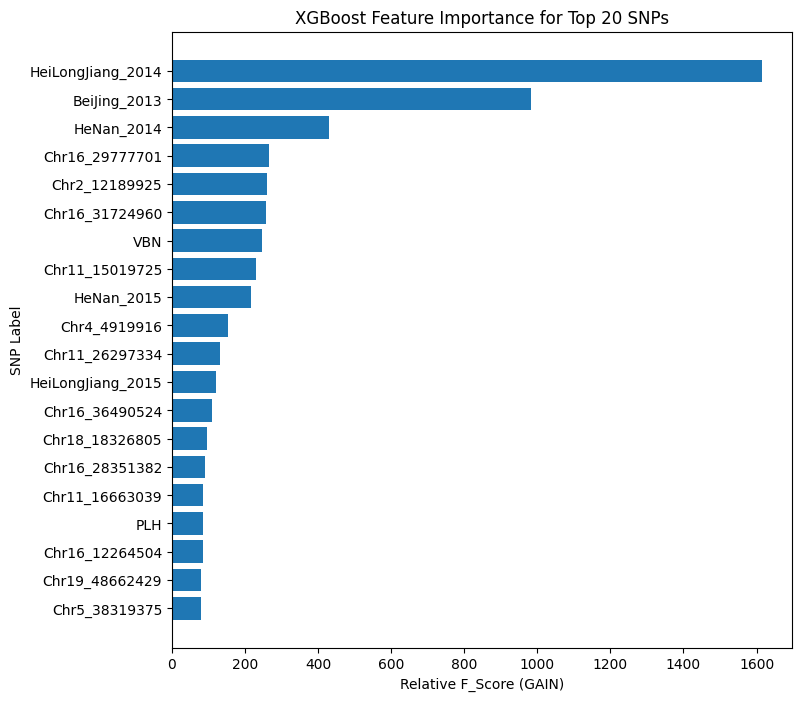

In [140]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, X_dupe, top_n=20)

In [141]:
explainer = shap.Explainer(best_xgbr_model)

In [142]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

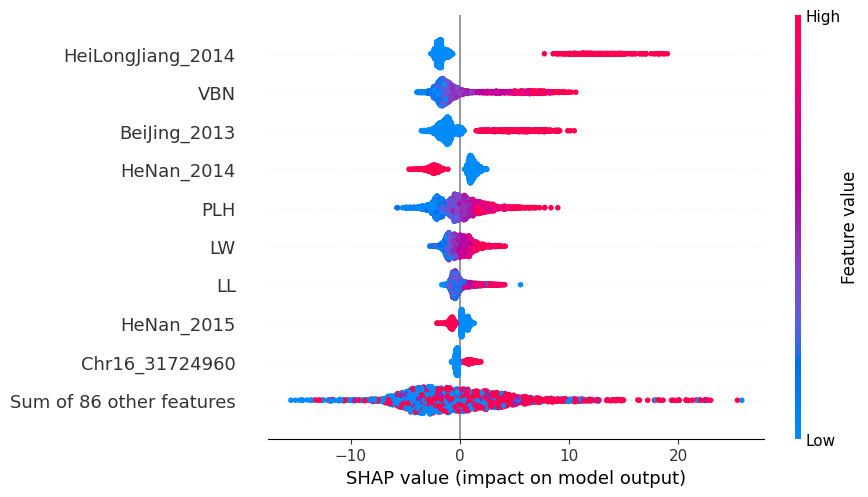

In [143]:
shap.plots.beeswarm(shap_values, show=False)

In [44]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [45]:
holdout_data = holdout_data.set_index('Line')

In [46]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [133]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [134]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [135]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [136]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Data columns (total 95 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Chr1_57654800      634 non-null    int64  
 1   Chr2_5531677       634 non-null    int64  
 2   Chr2_12189925      634 non-null    int64  
 3   Chr3_3015546       634 non-null    int64  
 4   Chr3_3928140       634 non-null    int64  
 5   Chr3_40005206      634 non-null    int64  
 6   Chr3_40290724      634 non-null    int64  
 7   Chr3_40656738      634 non-null    int64  
 8   Chr4_4857888       634 non-null    int64  
 9   Chr4_4919916       634 non-null    int64  
 10  Chr5_38319375      634 non-null    int64  
 11  Chr5_42876267      634 non-null    int64  
 12  Chr5_43891249      634 non-null    int64  
 13  Chr6_6382229       634 non-null    int64  
 14  Chr6_17486087      634 non-null    int64  
 15  Chr7_1665194       634 non-null    int64  
 16  Chr7_7688773       634 non-

In [137]:
y_holdout.shape

(634, 1)

In [138]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.64
RMSE of Holdout: 6.45
Mean of Holdout: 47.16
This is 13.67% of the mean pheno data
0 45 46.175827
1 39 47.65973
2 62 69.113
3 47 51.186436
4 42 45.276123
5 40 39.43205


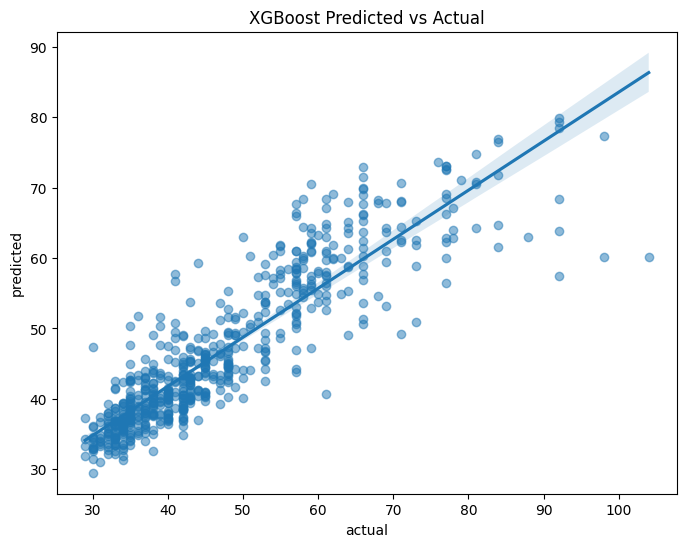

In [139]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [144]:
pickle.dump(best_xgbr_model, open("lasso_allfeats_xgbr_bbd.pickle.dat", "wb"))

In [54]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 20), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [55]:
best_rfr_model = eval_k_fold(best_rfreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5761270902139111
RMSE for dataset is:5.742097072132794& mean of this fold is 46.1496062992126
this is 12.44235332129099% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.27681539491042684
RMSE for dataset is:6.8197794314912805& mean of this fold is 44.889763779527556
this is 15.192281841771491% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3139219738349768
RMSE for dataset is:7.441701599661385& mean of this fold is 46.531496062992126
this is 15.99282685772055% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.49079892282441795
RMSE for dataset is:6.689818884472509& mean of this fold is 46.27165354330709
this is 14.45770438744165% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4912084272995676
RMSE for data

R^2 Value of Holdout: 0.32
RMSE of Holdout: 7.39
Mean of Holdout: 47.16
This is 15.67% of the mean pheno data
0 45 45.05345670995671
1 39 50.066
2 62 60.908
3 47 52.918
4 42 44.28
5 40 39.16701616161616


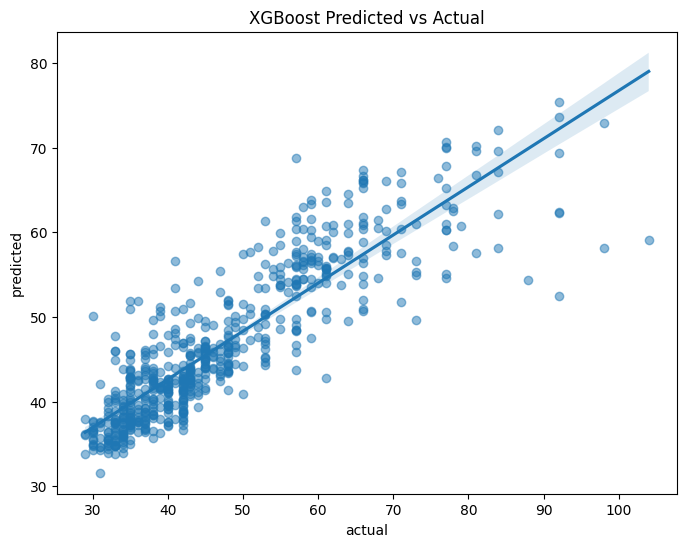

In [56]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [61]:
pickle.dump(best_rfr_model, open("lasso_allfeats_rfr_bbd.pickle.dat", "wb"))

In [57]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best SVR Parameters: OrderedDict([('epsilon', 1.5), ('kernel', 'poly')])


In [58]:
best_svr_model = eval_k_fold(best_svreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.0982461817879887
RMSE for dataset is:10.966122622690353& mean of this fold is 46.75590551181102
this is 23.453984053244778% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.7047656775658382
RMSE for dataset is:10.822662421304749& mean of this fold is 47.1496062992126
this is 22.953876544851422% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.0070751320100175
RMSE for dataset is:9.036378424007012& mean of this fold is 43.92125984251968
this is 20.574041947810876% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.487032060916704
RMSE for dataset is:10.4421458495802& mean of this fold is 44.94488188976378
this is 23.23322569896085% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.2778649670514928
RMSE for da

R^2 Value of Holdout: -2.79
RMSE of Holdout: 12.03
Mean of Holdout: 47.16
This is 25.50% of the mean pheno data
0 45 44.09044588959737
1 39 40.05250580103081
2 62 49.01867163785105
3 47 39.51045449268403
4 42 46.16331161073519
5 40 39.20090893846337


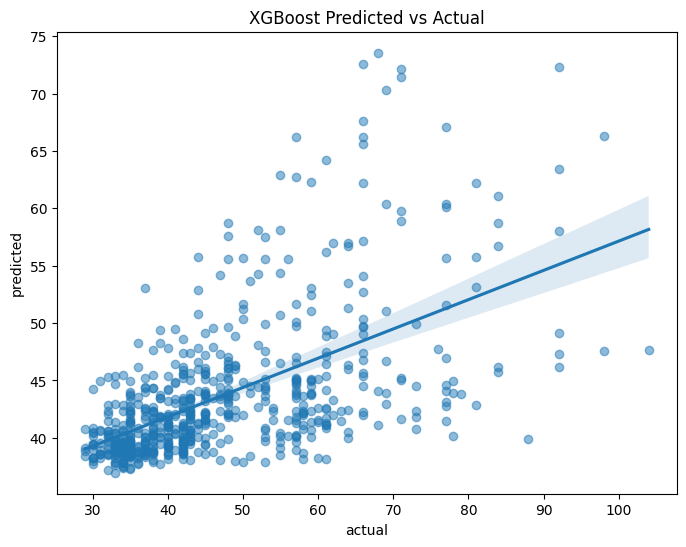

In [59]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

In [62]:
pickle.dump(best_svr_model, open("lasso_allfeats_svr_bbd.pickle.dat", "wb"))

## Only Location

In [145]:
snps_loc= fs_data.drop(['BBD', 'LL', 'LW', 'PLH', 'VBN'], axis=1)
snps_loc.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,Chr20_16221209,Chr20_40195415,Chr20_42765511,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,1,0,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,0,1,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,0,0,0,1,0,0,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,0,0,0,0,1,0,0,0,0,1


In [146]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Data columns (total 91 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Chr1_57654800      2536 non-null   int64
 1   Chr2_5531677       2536 non-null   int64
 2   Chr2_12189925      2536 non-null   int64
 3   Chr3_3015546       2536 non-null   int64
 4   Chr3_3928140       2536 non-null   int64
 5   Chr3_40005206      2536 non-null   int64
 6   Chr3_40290724      2536 non-null   int64
 7   Chr3_40656738      2536 non-null   int64
 8   Chr4_4857888       2536 non-null   int64
 9   Chr4_4919916       2536 non-null   int64
 10  Chr5_38319375      2536 non-null   int64
 11  Chr5_42876267      2536 non-null   int64
 12  Chr5_43891249      2536 non-null   int64
 13  Chr6_6382229       2536 non-null   int64
 14  Chr6_17486087      2536 non-null   int64
 15  Chr7_1665194       2536 non-null   int64
 16  Chr7_7688773       2536 non-null   int64
 17  Chr7_9531953     

In [147]:
snps_loc_dupe= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
snps_loc_dupe.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,Chr20_16221209,Chr20_40195415,Chr20_42765511,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,1,0,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,0,1,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,0,0,0,1,0,0,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,0,0,0,0,1,0,0,0,0,1


In [148]:
y_all = fs_data["BBD"].values

In [149]:
# Split training set into training and validation

In [150]:
X_train, X_test, y_train, y_test = train_test_split(snps_loc, y_all, test_size=0.1, random_state=42)

In [151]:
X_train = X_train.to_numpy()
#y_train = y_train.to_numpy()

In [152]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


In [153]:
snps_loc = snps_loc.to_numpy()
#y_all = y_all.to_numpy()
best_xgbr_model = eval_k_fold(best_xgbreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6915175625104999
RMSE for dataset is:5.732357183020668& mean of this fold is 45.173228346456696
this is 12.689722193544098% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5164984323330346
RMSE for dataset is:7.6197772910609025& mean of this fold is 46.381889763779526
this is 16.428345912311936% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6823216506407838
RMSE for dataset is:5.8408700007040935& mean of this fold is 44.381889763779526
this is 13.16048061899086% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5247766308894574
RMSE for dataset is:7.087378545705205& mean of this fold is 47.28740157480315
this is 14.98787903262944% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6778045569494557
RMSE for da

In [161]:
pickle.dump(best_xgbr_model, open("lasso_onlyloc_xgbr_bbd.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top5_onlyloc_xgbr_bbd.pickle.dat", "rb"))

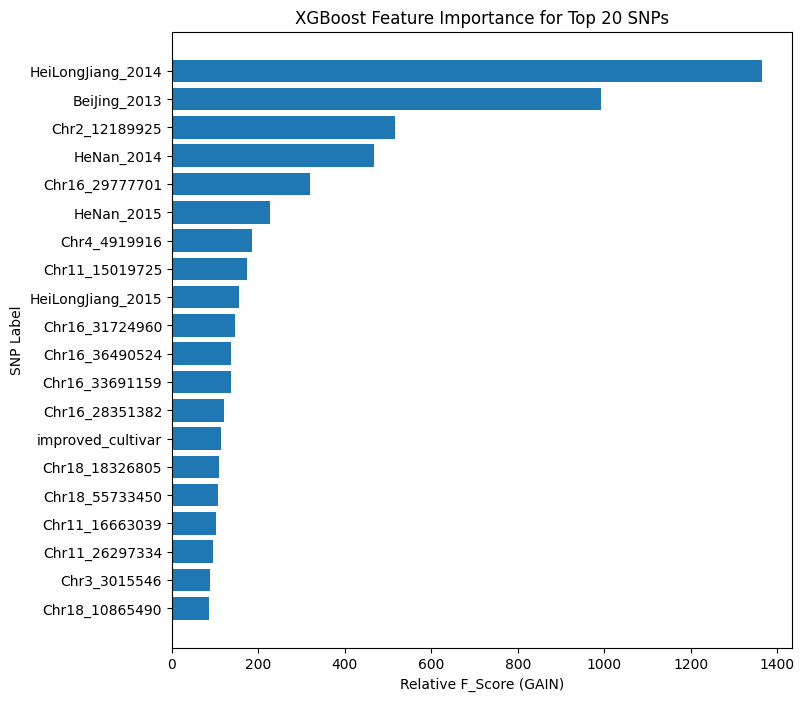

In [162]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, snps_loc_dupe, top_n=20)

In [163]:
explainer = shap.Explainer(best_xgbr_model)

In [164]:
shap_values = explainer(snps_loc_dupe, check_additivity=False)

<Axes: xlabel='SHAP value (impact on model output)'>

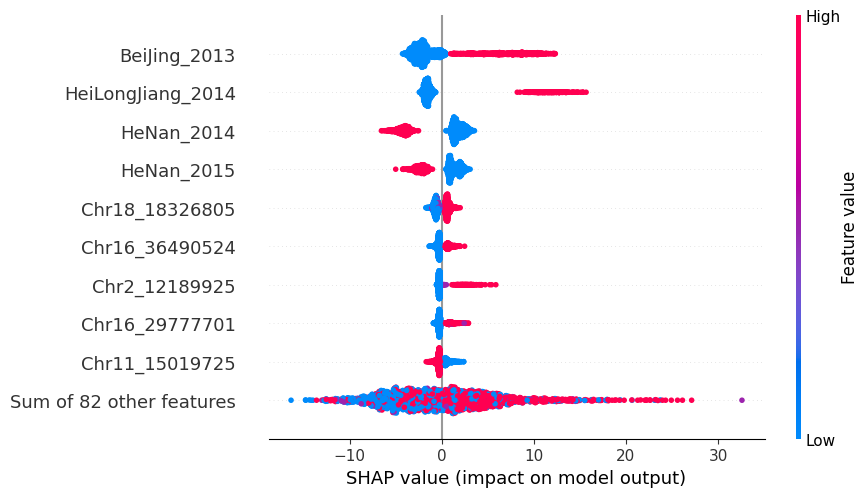

In [165]:
shap.plots.beeswarm(shap_values, show=False)

In [79]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [80]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [154]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [155]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [156]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [157]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Data columns (total 91 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Chr1_57654800      634 non-null    int64
 1   Chr2_5531677       634 non-null    int64
 2   Chr2_12189925      634 non-null    int64
 3   Chr3_3015546       634 non-null    int64
 4   Chr3_3928140       634 non-null    int64
 5   Chr3_40005206      634 non-null    int64
 6   Chr3_40290724      634 non-null    int64
 7   Chr3_40656738      634 non-null    int64
 8   Chr4_4857888       634 non-null    int64
 9   Chr4_4919916       634 non-null    int64
 10  Chr5_38319375      634 non-null    int64
 11  Chr5_42876267      634 non-null    int64
 12  Chr5_43891249      634 non-null    int64
 13  Chr6_6382229       634 non-null    int64
 14  Chr6_17486087      634 non-null    int64
 15  Chr7_1665194       634 non-null    int64
 16  Chr7_7688773       634 non-null    int64
 17  Chr7_9531953     

In [158]:
X_holdout.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,Chr20_16221209,Chr20_40195415,Chr20_42765511,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,2,0,2,0,0,...,0,0,0,0,0,1,0,0,0,1
s101,2,0,0,2,0,2,0,0,0,2,...,2,0,0,1,0,0,0,0,0,1
s101,2,0,0,2,0,2,0,0,0,2,...,2,0,0,0,0,0,1,0,0,1
s1026,0,0,0,0,0,2,0,2,0,2,...,0,2,0,0,0,0,0,1,0,1
s1030,0,0,0,0,2,0,0,0,0,2,...,1,0,2,0,1,0,0,0,0,1


In [159]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.53
RMSE of Holdout: 7.17
Mean of Holdout: 47.16
This is 15.21% of the mean pheno data
0 45 45.371338
1 39 45.358967
2 62 63.54779
3 47 52.1035
4 42 43.514297
5 40 41.994778


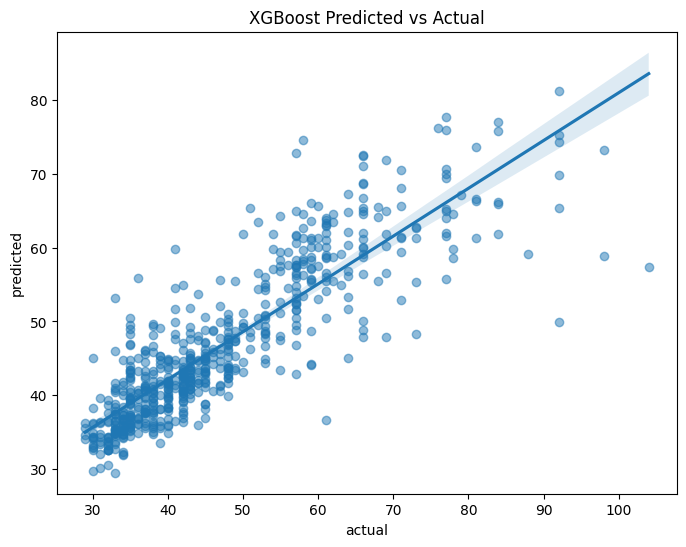

In [160]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [88]:
 # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 45 46.05171
1 39 46.03477
2 62 64.21407
3 47 53.45516
4 42 42.089157
5 40 41.37994


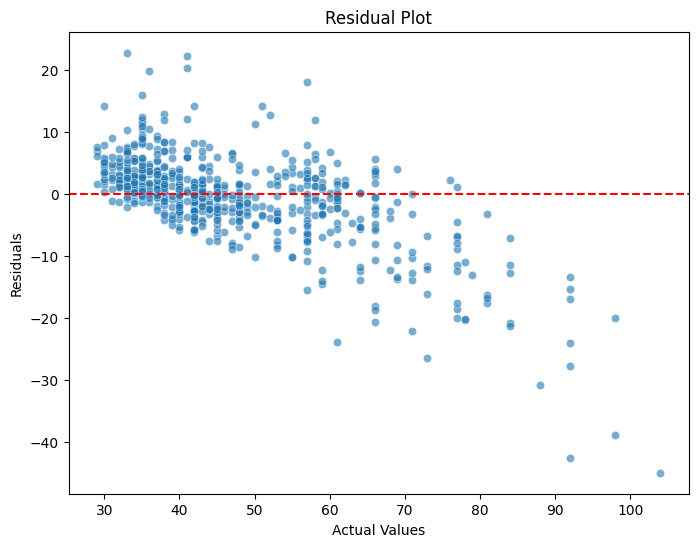

In [89]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [90]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 36), ('max_features', 'sqrt'), ('max_samples', 0.9843694271719634), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [91]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.11135282525574863
RMSE for dataset is:7.6306989859976815& mean of this fold is 46.34251968503937
this is 16.465869870388335% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.1040032914082355
RMSE for dataset is:8.050920893764472& mean of this fold is 45.91732283464567
this is 17.533515450708872% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4500860332956571
RMSE for dataset is:6.268494558503977& mean of this fold is 45.17716535433071
this is 13.875360504226666% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.153492835925772
RMSE for dataset is:7.624556667958699& mean of this fold is 47.460629921259844
this is 16.06501363468693% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.2370570198916797
RMSE for data

In [92]:
pickle.dump(best_rfr_model, open("lasso_onlyloc_rfr_bbd.pickle.dat", "wb"))

R^2 Value of Holdout: 0.04
RMSE of Holdout: 8.21
Mean of Holdout: 47.16
This is 17.40% of the mean pheno data
0 45 45.11
1 39 46.755
2 62 58.727
3 47 51.522
4 42 42.836
5 40 42.072


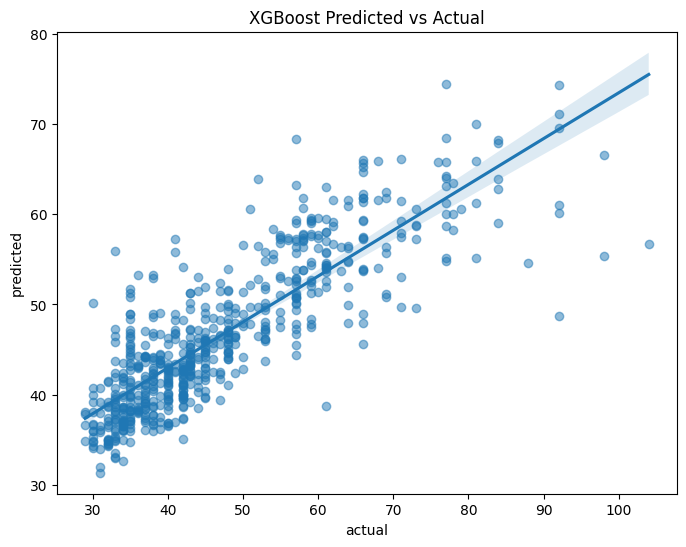

In [93]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [94]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best SVR Parameters: OrderedDict([('epsilon', 1.5), ('kernel', 'poly')])


In [95]:
best_svr_model = eval_k_fold(best_svreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.6765686744337336
RMSE for dataset is:9.385060322986302& mean of this fold is 45.27165354330709
this is 20.730544586820773% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.6359253624815782
RMSE for dataset is:9.09045084113074& mean of this fold is 46.96456692913386
this is 19.355977145168985% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.7691417703967225
RMSE for dataset is:9.126558740712186& mean of this fold is 46.610236220472444
this is 19.58058890227971% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.3125512280539526
RMSE for dataset is:9.669005289569512& mean of this fold is 46.83464566929134
this is 20.644984394339744% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.7512100748900439
RMSE for d

In [96]:
pickle.dump(best_svr_model, open("lasso_onlyloc_svr_bbd.pickle.dat", "wb"))

R^2 Value of Holdout: -1.18
RMSE of Holdout: 10.32
Mean of Holdout: 47.16
This is 21.88% of the mean pheno data
0 45 44.15763117171212
1 39 44.98108818645057
2 62 45.56411253780095
3 47 44.88191665358876
4 42 44.031874267793334
5 40 42.030559330064754


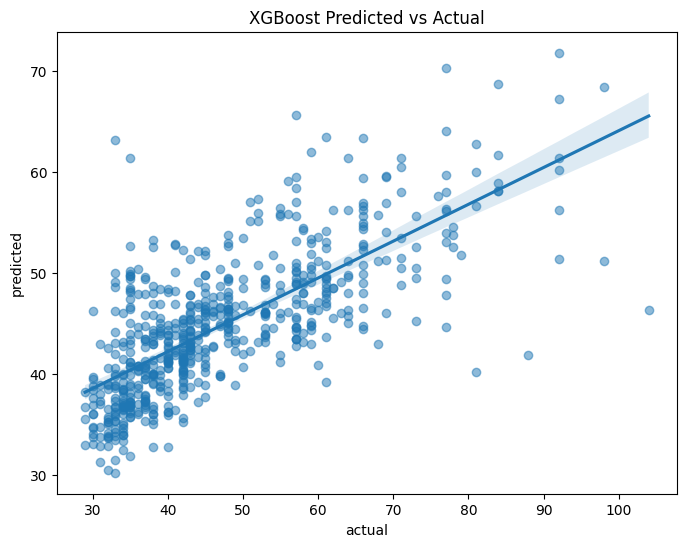

In [97]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

## Only snps

In [98]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Data columns (total 96 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Chr1_57654800      2536 non-null   int64  
 1   Chr2_5531677       2536 non-null   int64  
 2   Chr2_12189925      2536 non-null   int64  
 3   Chr3_3015546       2536 non-null   int64  
 4   Chr3_3928140       2536 non-null   int64  
 5   Chr3_40005206      2536 non-null   int64  
 6   Chr3_40290724      2536 non-null   int64  
 7   Chr3_40656738      2536 non-null   int64  
 8   Chr4_4857888       2536 non-null   int64  
 9   Chr4_4919916       2536 non-null   int64  
 10  Chr5_38319375      2536 non-null   int64  
 11  Chr5_42876267      2536 non-null   int64  
 12  Chr5_43891249      2536 non-null   int64  
 13  Chr6_6382229       2536 non-null   int64  
 14  Chr6_17486087      2536 non-null   int64  
 15  Chr7_1665194       2536 non-null   int64  
 16  Chr7_7688773       2536 non

In [99]:
only_snps = fs_data.iloc[:, 0:84]
only_snps.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,Chr19_43397236,Chr19_44387341,Chr19_48648920,Chr19_48662429,Chr19_50186921,Chr19_51600918,Chr20_2145196,Chr20_16221209,Chr20_40195415,Chr20_42765511
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s1014,0,0,0,0,0,2,0,2,0,0,...,2,0,0,0,0,2,2,0,0,0
s1014,0,0,0,0,0,2,0,2,0,0,...,2,0,0,0,0,2,2,0,0,0


In [100]:
only_snps_dupe = fs_data.iloc[:, 0:84]
only_snps.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,Chr19_43397236,Chr19_44387341,Chr19_48648920,Chr19_48662429,Chr19_50186921,Chr19_51600918,Chr20_2145196,Chr20_16221209,Chr20_40195415,Chr20_42765511
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s1014,0,0,0,0,0,2,0,2,0,0,...,2,0,0,0,0,2,2,0,0,0
s1014,0,0,0,0,0,2,0,2,0,0,...,2,0,0,0,0,2,2,0,0,0


In [101]:
y_all = fs_data["BBD"]
y_all.head()

Line
s100     61
s100     37
s100     43
s1014    77
s1014    42
Name: BBD, dtype: int64

### Run models

In [102]:
X_train, X_test, y_train, y_test = train_test_split(only_snps, y_all, test_size=0.1, random_state=42)

In [103]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [104]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.75636765570002), ('colsample_bytree', 0.03368606848987177), ('gamma', 6.9702079580470105e-09), ('learning_rate', 0.08386593798992044), ('max_delta_step', 18), ('max_depth', 38), ('min_child_weight', 3), ('n_estimators', 91), ('reg_alpha', 3.057144052430406e-08), ('reg_lambda', 9.595910417000342e-08), ('subsample', 0.7193541277075548)])


In [105]:
only_snps = only_snps.to_numpy()
y_all = y_all.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.82694870597042
RMSE for dataset is:11.867221251498869& mean of this fold is 45.91338582677165
this is 25.84697477174338% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.34049414164428
RMSE for dataset is:12.498630702270164& mean of this fold is 46.14173228346457
this is 27.087476095363666% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.178062830992565
RMSE for dataset is:12.104972348206546& mean of this fold is 46.51574803149607
this is 26.023385327502858% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.16341706767679
RMSE for dataset is:11.5526755807136& mean of this fold is 45.354330708661415
this is 25.472045117198395% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.990841838785385
RMSE for datase

In [106]:
pickle.dump(best_xgbr_model, open("lasso_onlysnps_xgbr_bbd.pickle.dat", "wb"))

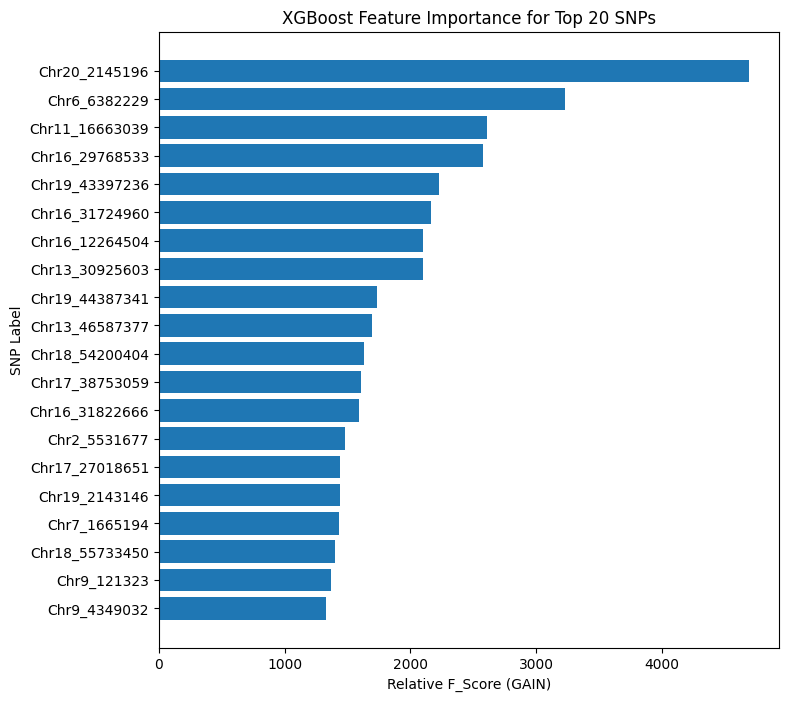

In [107]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, only_snps_dupe , top_n=20)

In [108]:
explainer = shap.Explainer(best_xgbr_model)

In [109]:
shap_values = explainer(only_snps_dupe)

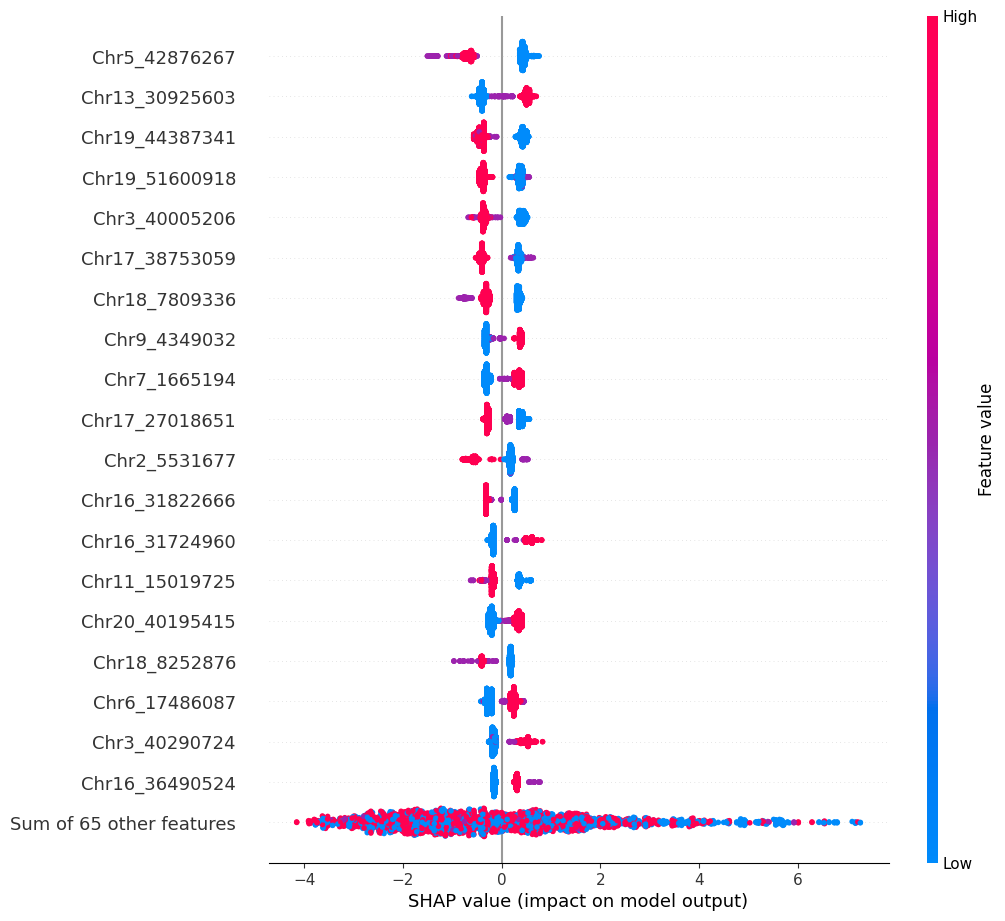

In [110]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])

In [111]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [112]:
holdout_data = holdout_data.set_index('Line')

In [113]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [114]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [115]:
# Ensure both trainjg and holdout datasets have the same columns
only_snps_dupe, X_holdout = only_snps_dupe.align(X_holdout, join='inner', axis=1)

In [116]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Data columns (total 84 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Chr1_57654800   634 non-null    int64
 1   Chr2_5531677    634 non-null    int64
 2   Chr2_12189925   634 non-null    int64
 3   Chr3_3015546    634 non-null    int64
 4   Chr3_3928140    634 non-null    int64
 5   Chr3_40005206   634 non-null    int64
 6   Chr3_40290724   634 non-null    int64
 7   Chr3_40656738   634 non-null    int64
 8   Chr4_4857888    634 non-null    int64
 9   Chr4_4919916    634 non-null    int64
 10  Chr5_38319375   634 non-null    int64
 11  Chr5_42876267   634 non-null    int64
 12  Chr5_43891249   634 non-null    int64
 13  Chr6_6382229    634 non-null    int64
 14  Chr6_17486087   634 non-null    int64
 15  Chr7_1665194    634 non-null    int64
 16  Chr7_7688773    634 non-null    int64
 17  Chr7_9531953    634 non-null    int64
 18  Chr7_39820318   634 non-null   

In [117]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -7.12
RMSE of Holdout: 13.04
Mean of Holdout: 47.16
This is 27.65% of the mean pheno data
0 45 47.82911
1 39 44.42767
2 62 44.42767
3 47 45.222332
4 42 49.10273
5 40 47.50569


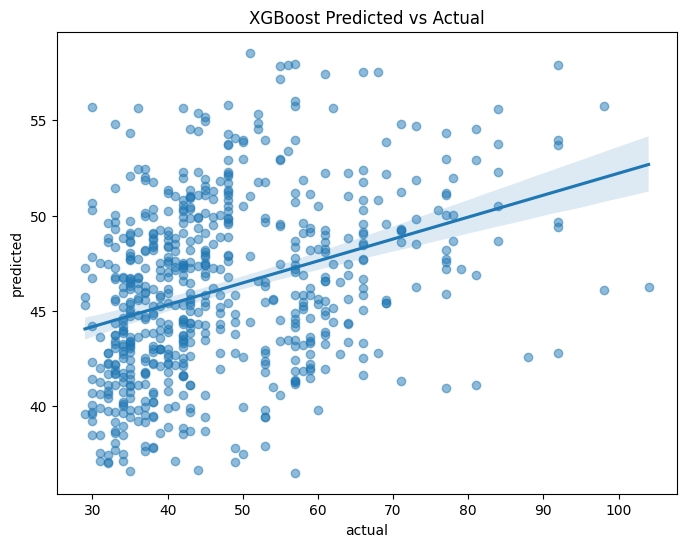

In [118]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [119]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 500)])


In [120]:
best_rfr_model = eval_k_fold(best_rfreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.037419578428978
RMSE for dataset is:10.620875146522867& mean of this fold is 45.79527559055118
this is 23.19207605929168% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.062317210690517
RMSE for dataset is:10.809570535981978& mean of this fold is 45.04724409448819
this is 23.996075127944607% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.119085359117946
RMSE for dataset is:12.847674763651725& mean of this fold is 45.968503937007874
this is 27.94886425117796% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.629992256206224
RMSE for dataset is:12.403877776546794& mean of this fold is 46.673228346456696
this is 26.57600130951401% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.542702926817103
RMSE for da

In [121]:
pickle.dump(best_rfr_model, open("lasso_onlysnps_rfr_bbd.pickle.dat", "wb"))

R^2 Value of Holdout: -6.38
RMSE of Holdout: 13.02
Mean of Holdout: 47.16
This is 27.60% of the mean pheno data
0 45 49.982204973512545
1 39 44.61902962429346
2 62 44.61902962429346
3 47 46.54181478329061
4 42 48.15894303096381
5 40 49.47342934265894


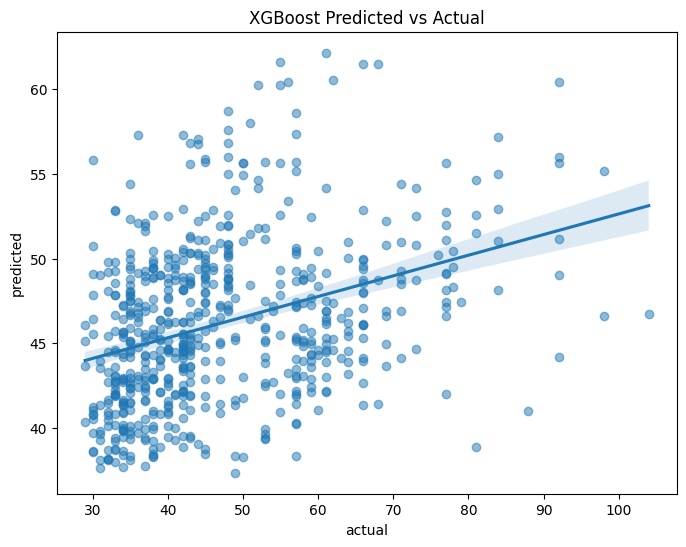

In [122]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [123]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best SVR Parameters: OrderedDict([('epsilon', 3), ('kernel', 'rbf')])


In [124]:
best_svr_model = eval_k_fold(best_svreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.635409897587962
RMSE for dataset is:11.294191875839589& mean of this fold is 44.330708661417326
this is 25.47712909825271% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.100669815659671
RMSE for dataset is:12.602766033162762& mean of this fold is 45.77952755905512
this is 27.529261888745626% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.117036081948243
RMSE for dataset is:13.757230725997909& mean of this fold is 47.56299212598425
this is 28.92423312973652% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.393918435391166
RMSE for dataset is:11.339484729758533& mean of this fold is 46.381889763779526
this is 24.44808693114903% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.414892091150638
RMSE for da

In [125]:
pickle.dump(best_svr_model, open("lasso_onlysnps_svr_bbd.pickle.dat", "wb"))

R^2 Value of Holdout: -8.46
RMSE of Holdout: 13.68
Mean of Holdout: 47.16
This is 29.01% of the mean pheno data
0 45 43.230286461196144
1 39 41.6685889400301
2 62 41.6685889400301
3 47 40.790605510459486
4 42 46.180141717665435
5 40 43.036613577290254


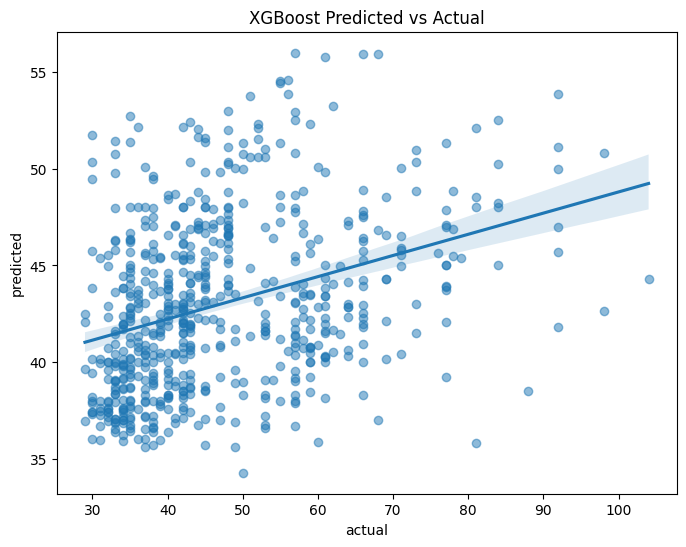

In [126]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)